# EDA: la ameba de fuego y el verdadero límite del calor

Este análisis utiliza los datos públicos de *Incendiamoeba cascadensis* para comprobar qué ocurre al aumentar la temperatura y para precisar el titular de Live Science.

La pregunta principal no es solo «¿hasta qué temperatura sobrevive?». El estudio mide capacidades diferentes:

- **reproducirse** de forma sostenida;
- **seguir moviéndose**;
- **resistir durante unos minutos** y recuperarse después.

Confundir esas tres pruebas produce un titular más espectacular, pero menos exacto.

**Fuentes**

- Estudio: https://doi.org/10.1016/j.cell.2026.08.043
- Datos y código de los autores: https://github.com/hbrappaport/incendiamoeba_manuscript
- Artículo analizado: https://www.livescience.com/planet-earth/evolution/newfound-fire-amoeba-from-the-cascades-sets-record-for-the-hottest-temperature-complex-life-can-survive-at
- NASA en español: https://ciencia.nasa.gov/ciencias-terrestres/investigacion-financiada-por-la-nasa-descubre-vida-compleja-que-desafia-un-calor-record/
- Publicación de NASA en X: https://x.com/NASA_es/status/2102480581103681568

## 1. Preparación del entorno

El notebook espera que los datos originales estén en `data/raw`. Los resultados se guardarán en `data/processed` y las imágenes en `img`.

In [1]:
# importo las librerías necesarias para el análisis
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# guardo las rutas principales del proyecto
ruta_proyecto = Path.cwd()
ruta_datos_raw = ruta_proyecto / "data" / "raw"
ruta_datos_processed = ruta_proyecto / "data" / "processed"
ruta_imagenes = ruta_proyecto / "img"

# creo las carpetas de salida si todavía no existen
ruta_datos_processed.mkdir(parents=True, exist_ok=True)
ruta_imagenes.mkdir(parents=True, exist_ok=True)

# defino una apariencia común para los gráficos
plt.style.use("seaborn-v0_8-whitegrid")
color_naranja = "#D85A30"
color_azul = "#446DDF"
color_lavanda = "#8B85C4"
color_tinta = "#1B1836"

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

## 2. Carga de los datos originales

Utilizaré dos archivos publicados por los investigadores:

- `growthcurves_individual.csv`: recuentos celulares por cultivo, temperatura y día.
- `incendi_doublingtimes.csv`: tiempos de duplicación calculados por los autores.

Los archivos originales no se modifican.

In [2]:
# construyo las rutas de los dos archivos originales
archivo_crecimiento = ruta_datos_raw / "growthcurves_individual.csv"
archivo_duplicacion = ruta_datos_raw / "incendi_doublingtimes.csv"

# cargo los datos publicados por los autores
df_crecimiento_raw = pd.read_csv(archivo_crecimiento, encoding="utf-8")
df_duplicacion_raw = pd.read_csv(archivo_duplicacion, encoding="utf-8")

print("tabla de crecimiento:", df_crecimiento_raw.shape)
display(df_crecimiento_raw.head())

print("tabla de tiempos de duplicación:", df_duplicacion_raw.shape)
display(df_duplicacion_raw.head())

tabla de crecimiento: (924, 6)


,Sample_ID,Batch_ID,Temp,TempC,Time,Cell_mL
0,30_1,30A,30.00,30C,0,"25,000.00"
1,30_2,30A,30.00,30C,0,"20,000.00"
2,30_3,30A,30.00,30C,0,"27,500.00"
3,30_4,30A,30.00,30C,0,"25,000.00"
4,40_1,40A,40.00,40C,0,"17,500.00"


tabla de tiempos de duplicación: (24, 5)


,Temperature,days to calculate doubling time,Replicate,Average Doubling Time (Exponential portion_hours),Best_batch
0,42.00,"4,7",42A,126.00,True
1,42.00,"5,7",42B,61.40,False
2,43.00,"4,7",43A,86.40,True
3,44.00,"3,7",44A,105.50,True
4,45.00,"4,7",45A,81.00,True


### 2.1. Revisión estructural

Antes de calcular nada, compruebo los tipos de las columnas, los valores ausentes y los posibles registros duplicados.

In [3]:
# reviso la estructura de la tabla de crecimiento
df_crecimiento_raw.info()

# cuento los valores ausentes y los duplicados exactos
revision_inicial = pd.DataFrame({
    "valores_ausentes": df_crecimiento_raw.isna().sum(),
    "tipo": df_crecimiento_raw.dtypes.astype(str),
})

display(revision_inicial)
print("duplicados exactos:", df_crecimiento_raw.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Sample_ID  924 non-null    str    
 1   Batch_ID   924 non-null    str    
 2   Temp       924 non-null    float64
 3   TempC      924 non-null    str    
 4   Time       924 non-null    int64  
 5   Cell_mL    864 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 53.4 KB


,valores_ausentes,tipo
Sample_ID,0,str
Batch_ID,0,str
Temp,0,float64
TempC,0,str
Time,0,int64
Cell_mL,60,float64


duplicados exactos: 0


La tabla contiene **924 registros**. Sesenta no incluyen un recuento celular válido, por lo que se conservarán en el archivo original, pero no podrán intervenir en los cálculos de crecimiento.

## 3. Limpieza y comprobación de los identificadores

`Sample_ID` identifica cada cultivo a lo largo de los días. Al cruzarlo con `Batch_ID` aparecen dos filas aisladas cuyo lote no coincide con el resto de su propia serie temporal.

No crearé cultivos nuevos a partir de esas dos etiquetas anómalas. Conservaré los datos originales y utilizaré `Sample_ID` como identificador de la trayectoria completa.

In [4]:
# creo una copia de trabajo sin alterar los datos originales
df_crecimiento = df_crecimiento_raw.copy()

# convierto las variables numéricas y mantengo los valores no válidos como ausentes
columnas_numericas = ["Temp", "Time", "Cell_mL"]
for columna in columnas_numericas:
    df_crecimiento[columna] = pd.to_numeric(
        df_crecimiento[columna],
        errors="coerce",
    )

# localizo las muestras que aparecen asociadas a más de un lote
muestras_con_lote_inconsistente = (
    df_crecimiento.groupby("Sample_ID")["Batch_ID"]
    .nunique()
    .loc[lambda serie: serie > 1]
)

filas_lote_inconsistente = df_crecimiento.loc[
    df_crecimiento["Sample_ID"].isin(muestras_con_lote_inconsistente.index),
    ["Sample_ID", "Batch_ID", "Temp", "Time", "Cell_mL"],
].sort_values(["Sample_ID", "Time"])

display(filas_lote_inconsistente)

# uso Sample_ID para mantener unida la serie temporal de cada cultivo
df_crecimiento["cultivo_id"] = df_crecimiento["Sample_ID"].astype(str)

print("muestras con alguna etiqueta de lote inconsistente:", len(muestras_con_lote_inconsistente))
print("cultivos únicos correctamente identificados:", df_crecimiento["cultivo_id"].nunique())

,Sample_ID,Batch_ID,Temp,Time,Cell_mL
616,63_9,63A,63.00,0,"7,500.00"
632,63_9,63A,63.00,1,"20,000.00"
648,63_9,63C,63.00,2,"20,000.00"
664,63_9,63A,63.00,3,"20,000.00"
680,63_9,63A,63.00,4,"17,500.00"
696,63_9,63A,63.00,5,"22,500.00"
712,63_9,63A,63.00,6,"40,000.00"
728,63_9,63A,63.00,7,"32,500.00"
620,64_5,64B,64.00,0,"25,000.00"
636,64_5,64B,64.00,1,"20,000.00"


muestras con alguna etiqueta de lote inconsistente: 2
cultivos únicos correctamente identificados: 116


#### Resultado de la comprobación

Hay **116 cultivos únicos**. Las dos incoherencias corresponden a una sola medición intermedia de `63_9` y otra de `64_5`; el resto de cada trayectoria mantiene un lote estable. Separarlas por `Batch_ID` inventaría dos cultivos sin medición inicial. Usar `Sample_ID` conserva correctamente las series temporales.

In [5]:
# elimino solo las filas sin los valores imprescindibles para el cálculo
df_valido = df_crecimiento.dropna(
    subset=["Temp", "Time", "Cell_mL", "cultivo_id"]
).copy()

# compruebo si existe más de una medición para el mismo cultivo y día
duplicados_medicion = df_valido.duplicated(
    subset=["cultivo_id", "Time"],
    keep=False,
)

print("registros originales:", len(df_crecimiento))
print("registros con recuento válido:", len(df_valido))
print("mediciones repetidas para un mismo cultivo y día:", duplicados_medicion.sum())

registros originales: 924
registros con recuento válido: 864
mediciones repetidas para un mismo cultivo y día: 0


## 4. Cobertura del experimento

Reviso cuántas temperaturas, lotes y cultivos hay, y hasta qué día llega cada ensayo. Esto evita comparar como equivalentes temperaturas con distinta duración o número de réplicas.

In [6]:
# resumo la cobertura experimental de cada temperatura
cobertura = (
    df_valido.groupby("Temp")
    .agg(
        lotes=("Batch_ID", "nunique"),
        cultivos=("cultivo_id", "nunique"),
        dias_observados=("Time", "nunique"),
        ultimo_dia=("Time", "max"),
    )
    .reset_index()
    .rename(columns={"Temp": "temperatura_c"})
)

display(cobertura)
print("temperaturas estudiadas:", cobertura["temperatura_c"].nunique())
print("cultivos únicos:", df_valido["cultivo_id"].nunique())

,temperatura_c,lotes,cultivos,dias_observados,ultimo_dia
0,30.00,1,4,7,7
1,40.00,1,4,7,7
2,42.00,3,12,8,7
3,43.00,1,4,8,7
4,44.00,1,4,8,7
5,45.00,1,4,7,7
6,50.00,1,4,7,7
7,51.50,1,4,7,7
8,54.00,1,4,8,7
9,55.00,4,16,8,7


temperaturas estudiadas: 17
cultivos únicos: 116


El experimento cubre **17 temperaturas**. No todas llegan al día 7: por eso la comparación final indicará cuántas réplicas sostienen cada resultado.

## 5. Normalización del crecimiento

Los cultivos no comienzan siempre con la misma densidad celular. Comparar directamente células por mililitro podría confundir una siembra inicial más alta con un crecimiento mejor.

Para cada cultivo divido cada recuento por su valor del día 0:

`factor de crecimiento = densidad del día observado / densidad del día 0`

Un valor de 1 significa que el cultivo termina con la misma densidad con la que comenzó. Por encima de 1 hay crecimiento neto; por debajo de 1, pérdida neta.

In [7]:
# recupero la densidad inicial de cada cultivo
densidad_inicial = (
    df_valido.loc[df_valido["Time"] == 0, ["cultivo_id", "Cell_mL"]]
    .rename(columns={"Cell_mL": "densidad_inicial"})
)

# compruebo que cada cultivo tenga una sola medición inicial
assert densidad_inicial["cultivo_id"].is_unique

# añado la densidad inicial y calculo el factor de crecimiento
df_normalizado = df_valido.merge(
    densidad_inicial,
    on="cultivo_id",
    how="left",
    validate="many_to_one",
)

df_normalizado["factor_crecimiento"] = (
    df_normalizado["Cell_mL"]
    / df_normalizado["densidad_inicial"]
)

# verifico que todas las mediciones del día 0 sean iguales a 1
comprobacion_dia_0 = df_normalizado.loc[
    df_normalizado["Time"] == 0,
    "factor_crecimiento",
]
assert np.allclose(comprobacion_dia_0, 1)

display(df_normalizado.head())

,Sample_ID,Batch_ID,Temp,TempC,Time,Cell_mL,cultivo_id,densidad_inicial,factor_crecimiento
0,30_1,30A,30.00,30C,0,"25,000.00",30_1,"25,000.00",1.00
1,30_2,30A,30.00,30C,0,"20,000.00",30_2,"20,000.00",1.00
2,30_3,30A,30.00,30C,0,"27,500.00",30_3,"27,500.00",1.00
3,30_4,30A,30.00,30C,0,"25,000.00",30_4,"25,000.00",1.00
4,40_1,40A,40.00,40C,0,"17,500.00",40_1,"17,500.00",1.00


## 6. Qué queda de cada cultivo al séptimo día

La mediana describe mejor el resultado típico que la media porque algunas réplicas crecen mucho más que otras. También calcularé los percentiles 25 y 75 para mostrar la variabilidad.

In [8]:
# selecciono únicamente las mediciones realizadas en el día 7
df_dia7 = df_normalizado.loc[df_normalizado["Time"] == 7].copy()

# resumo el resultado de las réplicas por temperatura
resumen_dia7 = (
    df_dia7.groupby("Temp")
    .agg(
        replicas=("factor_crecimiento", "count"),
        factor_mediano=("factor_crecimiento", "median"),
        factor_p25=("factor_crecimiento", lambda serie: serie.quantile(0.25)),
        factor_p75=("factor_crecimiento", lambda serie: serie.quantile(0.75)),
        cultivos_con_crecimiento=("factor_crecimiento", lambda serie: (serie > 1).sum()),
    )
    .reset_index()
    .rename(columns={"Temp": "temperatura_c"})
)

resumen_dia7["porcentaje_con_crecimiento"] = (
    resumen_dia7["cultivos_con_crecimiento"]
    / resumen_dia7["replicas"]
    * 100
)

display(resumen_dia7)

# guardo la tabla procesada sin modificar los archivos originales
resumen_dia7.to_csv(
    ruta_datos_processed / "resumen_crecimiento_dia7.csv",
    index=False,
    encoding="utf-8-sig",
)

,temperatura_c,replicas,factor_mediano,factor_p25,factor_p75,cultivos_con_crecimiento,porcentaje_con_crecimiento
0,30.00,4,0.55,0.47,0.63,0,0.00
1,40.00,4,0.98,0.58,1.29,2,50.00
2,42.00,12,1.44,0.97,1.80,8,66.67
3,43.00,4,1.45,1.34,1.53,4,100.00
4,44.00,4,1.73,1.62,1.78,4,100.00
5,45.00,4,2.21,1.62,2.87,3,75.00
6,50.00,4,2.46,2.13,2.75,4,100.00
7,51.50,4,5.28,3.70,6.83,4,100.00
8,54.00,4,3.33,2.95,4.24,4,100.00
9,55.00,12,3.83,2.62,4.74,12,100.00


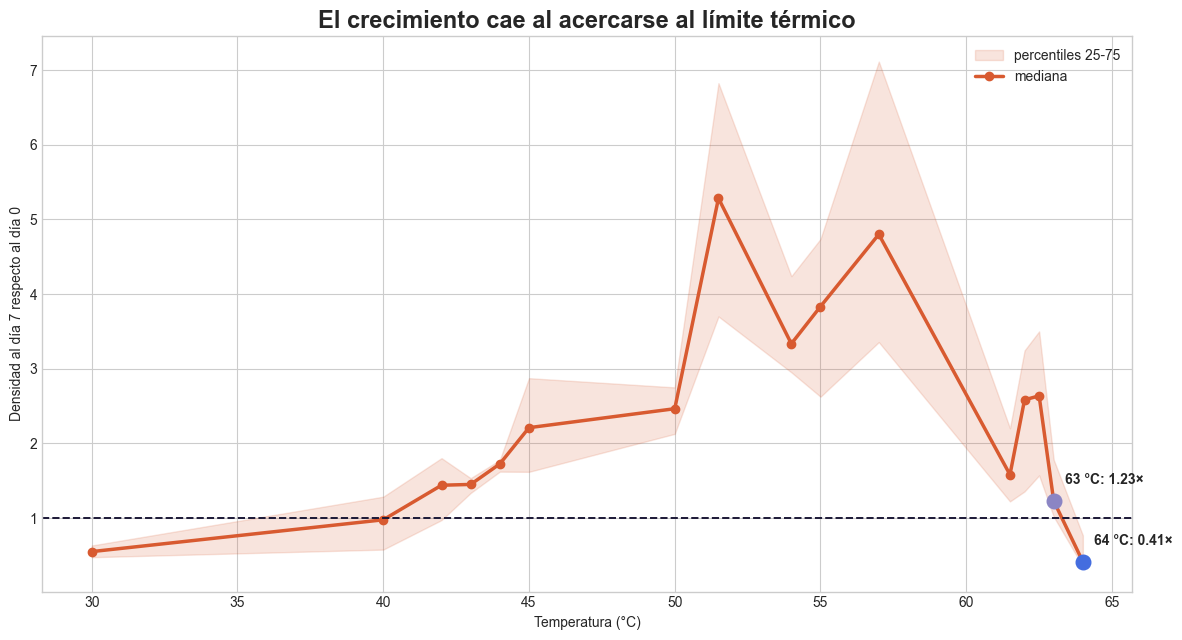

In [9]:
# represento la mediana y el intervalo central de las réplicas
fig, ax = plt.subplots(figsize=(12, 6.5))

x = resumen_dia7["temperatura_c"]
y = resumen_dia7["factor_mediano"]

ax.fill_between(
    x,
    resumen_dia7["factor_p25"],
    resumen_dia7["factor_p75"],
    color=color_naranja,
    alpha=0.16,
    label="percentiles 25-75",
)
ax.plot(x, y, color=color_naranja, marker="o", linewidth=2.5, label="mediana")
ax.axhline(1, color=color_tinta, linestyle="--", linewidth=1.4)

# destaco los dos lados del límite de reproducción
for temperatura, color in [(63, color_lavanda), (64, color_azul)]:
    fila = resumen_dia7.loc[resumen_dia7["temperatura_c"] == temperatura].iloc[0]
    ax.scatter(
        fila["temperatura_c"],
        fila["factor_mediano"],
        s=110,
        color=color,
        zorder=5,
    )
    ax.annotate(
        f"{temperatura} °C: {fila['factor_mediano']:.2f}×",
        (fila["temperatura_c"], fila["factor_mediano"]),
        xytext=(8, 12),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("El crecimiento cae al acercarse al límite térmico", fontsize=17, fontweight="bold")
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Densidad al día 7 respecto al día 0")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ruta_imagenes / "01_crecimiento_dia7.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Cómo se degrada el crecimiento cerca del límite

Para observar la transición completa, comparo las curvas medianas de las temperaturas próximas al máximo.

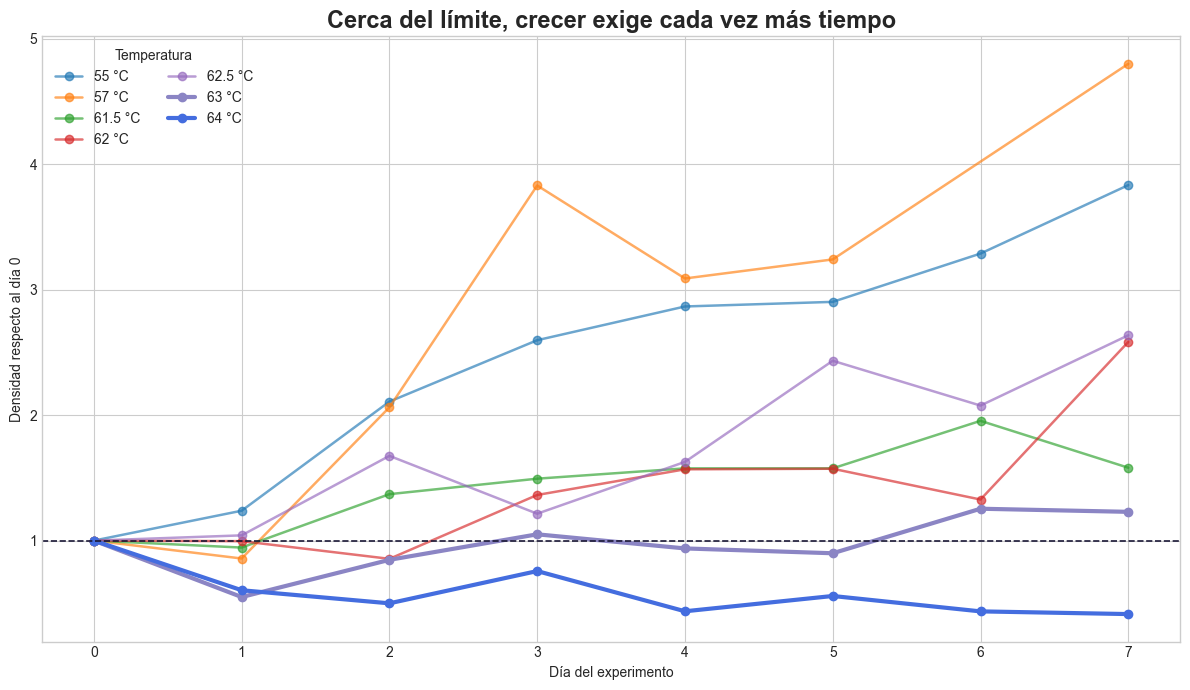

In [10]:
# selecciono las temperaturas próximas al límite superior
temperaturas_limite = [55, 57, 61.5, 62, 62.5, 63, 64]

curvas_limite = (
    df_normalizado.loc[df_normalizado["Temp"].isin(temperaturas_limite)]
    .groupby(["Temp", "Time"], as_index=False)
    .agg(factor_mediano=("factor_crecimiento", "median"))
)

# dibujo una curva mediana para cada temperatura
fig, ax = plt.subplots(figsize=(12, 7))

for temperatura, grupo in curvas_limite.groupby("Temp"):
    color = color_lavanda if temperatura == 63 else (
        color_azul if temperatura == 64 else None
    )
    ax.plot(
        grupo["Time"],
        grupo["factor_mediano"],
        marker="o",
        linewidth=3 if temperatura in [63, 64] else 1.8,
        alpha=1 if temperatura in [63, 64] else 0.65,
        color=color,
        label=f"{temperatura:g} °C",
    )

ax.axhline(1, color=color_tinta, linestyle="--", linewidth=1.2)
ax.set_title("Cerca del límite, crecer exige cada vez más tiempo", fontsize=17, fontweight="bold")
ax.set_xlabel("Día del experimento")
ax.set_ylabel("Densidad respecto al día 0")
ax.legend(title="Temperatura", ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(ruta_imagenes / "02_curvas_limite.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretación

El límite de 63 °C no significa que la ameba funcione igual que a su temperatura preferida. La población avanza con dificultad y algunas réplicas retroceden. A 64 °C puede quedar actividad celular, pero la población ya no se sostiene mediante reproducción.

## 8. Tiempo necesario para duplicar la población

Los autores calcularon el tiempo medio de duplicación durante la fase exponencial y marcaron un lote de referencia como `Best_batch` para cada temperatura. Utilizo esa selección para no escoger arbitrariamente entre lotes.

In [11]:
# preparo la tabla de tiempos de duplicación
df_duplicacion = df_duplicacion_raw.copy()
df_duplicacion["Temperature"] = pd.to_numeric(
    df_duplicacion["Temperature"],
    errors="coerce",
)
df_duplicacion["horas_duplicacion"] = pd.to_numeric(
    df_duplicacion["Average Doubling Time (Exponential portion_hours)"],
    errors="coerce",
)

# convierto la marca de lote seleccionado a un valor lógico
df_duplicacion["es_lote_referencia"] = (
    df_duplicacion["Best_batch"]
    .astype(str)
    .str.upper()
    .eq("TRUE")
)

duplicacion_referencia = (
    df_duplicacion.loc[df_duplicacion["es_lote_referencia"]]
    .sort_values("Temperature")
    .copy()
)

display(
    duplicacion_referencia[
        ["Temperature", "Replicate", "horas_duplicacion"]
    ]
)

,Temperature,Replicate,horas_duplicacion
0,42.00,42A,126.00
2,43.00,43A,86.40
3,44.00,44A,105.50
4,45.00,45A,81.00
5,50.00,50A,64.80
6,51.50,51.5A,51.40
7,54.00,54A,35.00
8,55.00,55A,36.90
12,57.00,57A,29.80
13,61.00,61A,39.40


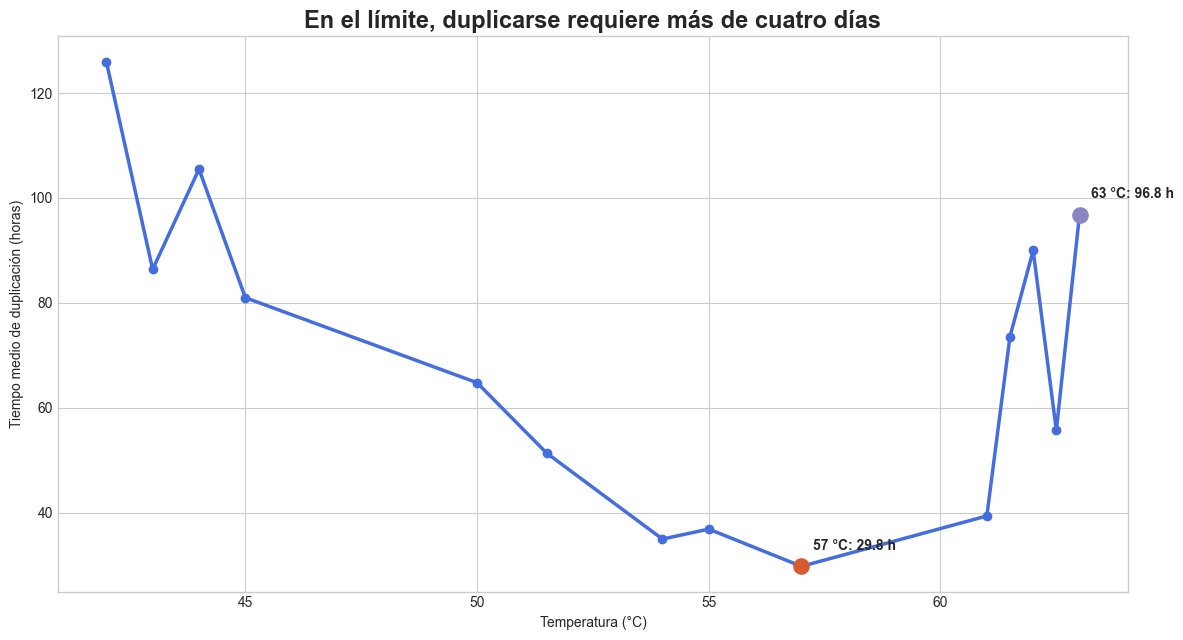

In [12]:
# represento las horas necesarias para duplicar la población
fig, ax = plt.subplots(figsize=(12, 6.5))

ax.plot(
    duplicacion_referencia["Temperature"],
    duplicacion_referencia["horas_duplicacion"],
    color=color_azul,
    marker="o",
    linewidth=2.5,
)

for temperatura, color in [(57, color_naranja), (63, color_lavanda)]:
    fila = duplicacion_referencia.loc[
        duplicacion_referencia["Temperature"] == temperatura
    ].iloc[0]
    ax.scatter(
        fila["Temperature"],
        fila["horas_duplicacion"],
        color=color,
        s=120,
        zorder=5,
    )
    ax.annotate(
        f"{temperatura} °C: {fila['horas_duplicacion']:.1f} h",
        (fila["Temperature"], fila["horas_duplicacion"]),
        xytext=(8, 12),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("En el límite, duplicarse requiere más de cuatro días", fontsize=17, fontweight="bold")
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Tiempo medio de duplicación (horas)")
fig.tight_layout()
fig.savefig(ruta_imagenes / "03_tiempo_duplicacion.png", dpi=180, bbox_inches="tight")
plt.show()

In [13]:
# comparo la temperatura de crecimiento más rápido con el límite de 63 °C
fila_mas_rapida = duplicacion_referencia.loc[
    duplicacion_referencia["horas_duplicacion"].idxmin()
]
fila_63 = duplicacion_referencia.loc[
    duplicacion_referencia["Temperature"] == 63
].iloc[0]

relacion_lentitud = (
    fila_63["horas_duplicacion"]
    / fila_mas_rapida["horas_duplicacion"]
)

print(
    f"La duplicación más rápida aparece a {fila_mas_rapida['Temperature']:g} °C: "
    f"{fila_mas_rapida['horas_duplicacion']:.1f} horas."
)
print(
    f"A 63 °C necesita {fila_63['horas_duplicacion']:.1f} horas: "
    f"{relacion_lentitud:.2f} veces más."
)

La duplicación más rápida aparece a 57 °C: 29.8 horas.
A 63 °C necesita 96.8 horas: 3.25 veces más.


### Interpretación

El máximo térmico no coincide con el mejor funcionamiento. La reproducción más rápida del lote de referencia ocurre a 57 °C, con una duplicación cada 29,8 horas. A 63 °C hacen falta 96,8 horas: **3,25 veces más tiempo**.

Este dato permite contar el límite como una pérdida gradual de rendimiento, no como un interruptor que pasa de «viva» a «muerta».

## 9. La corrección del artículo y la aportación de NASA

Los datos de crecimiento permiten verificar directamente el límite de reproducción. El estudio y la noticia de NASA añaden dos escalones que el primer resumen dejaba fuera: actividad parcial a 66 °C y ausencia de recuperación tras 80 °C.

Las observaciones individuales de movimiento, enquistamiento y recuperación no están incluidas en los CSV de crecimiento utilizados aquí, por lo que esos resultados se citan y no se recalculan.

In [14]:
# separo los tres límites para no presentar pruebas distintas como un único récord
limites = pd.DataFrame({
    "capacidad": [
        "Reproducción sostenida",
        "Movimiento",
        "Actividad parcial",
        "Recuperación tras calor breve",
        "Recuperación tras calor extremo",
    ],
    "temperatura_c": [63, 64, 66, 70, 80],
    "resultado": [
        "Sí crece y se divide",
        "Movimiento cuantificado, sin crecimiento neto",
        "Se redondea y sigue parcialmente activa; posible inicio del enquistamiento",
        "Se enquista y se recupera después de 5 minutos",
        "No se recuperó en el ensayo",
    ],
    "evidencia_usada": [
        "CSV de crecimiento y estudio",
        "Estudio y NASA; sin datos individuales en este paquete",
        "Estudio y NASA; sin datos individuales en este paquete",
        "Estudio; exposición de solo 5 minutos",
        "Estudio; resultado del ensayo",
    ],
})

display(limites)
limites.to_csv(
    ruta_datos_processed / "limites_termicos.csv",
    index=False,
    encoding="utf-8-sig",
)

,capacidad,temperatura_c,resultado,evidencia_usada
0,Reproducción sostenida,63,Sí crece y se divide,CSV de crecimiento y estudio
1,Movimiento,64,"Movimiento cuantificado, sin crecimiento neto",Estudio y NASA; sin datos individuales en este...
2,Actividad parcial,66,Se redondea y sigue parcialmente activa; posib...,Estudio y NASA; sin datos individuales en este...
3,Recuperación tras calor breve,70,Se enquista y se recupera después de 5 minutos,Estudio; exposición de solo 5 minutos
4,Recuperación tras calor extremo,80,No se recuperó en el ensayo,Estudio; resultado del ensayo


## 10. Límites del análisis

- Los datos de crecimiento no incluyen las observaciones individuales de movimiento a 64 °C, actividad parcial a 66 °C ni recuperación tras 70 °C. Esos resultados se citan desde el estudio y NASA y no se recalculan aquí.
- El ensayo de 70 °C duró cinco minutos. No demuestra crecimiento continuo ni supervivencia indefinida a esa temperatura.
- Los tamaños de muestra cambian según la temperatura. Las conclusiones deben mostrar el número de réplicas.
- El archivo de tiempos de duplicación contiene una selección `Best_batch` realizada por los autores. El notebook la conserva y la declara de forma explícita.
- Las explicaciones sobre proteínas más estables se apoyan en parte en predicciones computacionales. Son hipótesis compatibles con los datos, no una causa demostrada por este EDA.

## 11. Conclusiones

1. **El récord importante es de reproducción:** la ameba todavía aumenta su población a 63 °C.
2. **Sobrevivir no equivale a prosperar:** a 63 °C la duplicación tarda 96,8 horas, frente a 29,8 horas a 57 °C.
3. **A 64 °C queda actividad, pero no crecimiento neto:** la mediana termina en 0,41 veces la densidad inicial.
4. **Los 66 °C añaden un estado intermedio:** las células se redondean y siguen parcialmente activas, probablemente al comenzar a enquistarse.
5. **Los 70 °C requieren contexto:** la recuperación se observó después de una exposición de cinco minutos y mediante enquistamiento.
6. **NASA en español contiene una errata verificable:** invierte 176 °F y 80 °C.
7. **El mejor ángulo para Nebula es la pérdida progresiva de capacidades:** primero se ralentiza la reproducción, después desaparece el crecimiento neto, luego queda movimiento, actividad parcial y finalmente solo una resistencia breve en forma de quiste.

Esta separación hace que la historia sea más exacta y también más entretenida: no hay una única frontera de la vida, sino varias puertas que se van cerrando una detrás de otra.